In [5]:
# Importar las librerías
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
# Crear la red o mapa del nivel
mapa_juego = nx.DiGraph()

In [9]:
# Mapa de juego
conexiones_nivel = [
    ("Spawn_Point", "Armeria", 10),
    ("Spawn_Point", "Trampa_Picos", 25),
    ("Armeria", "Biblioteca", 15),
    ("Armeria", "Trampa_Picos", 10),
    ("Trampa_Picos", "Puente_Lava", 30),
    ("Biblioteca", "Puente_Lava", 12),
    ("Biblioteca", "Cuarto_Jefe", 40),
    ("Puente_Lava", "Cuarto_Jefe", 15)
]
for origen, destino, costo in conexiones_nivel:
    mapa_juego.add_edge(origen, destino, weight=costo)
print(f"Total de Zonas/Habitaciones (Nodos): {mapa_juego.number_of_nodes()}")
print(f"Total de Pasillos/Conexiones (Aristas): {mapa_juego.number_of_edges()}")

Total de Zonas/Habitaciones (Nodos): 6
Total de Pasillos/Conexiones (Aristas): 8


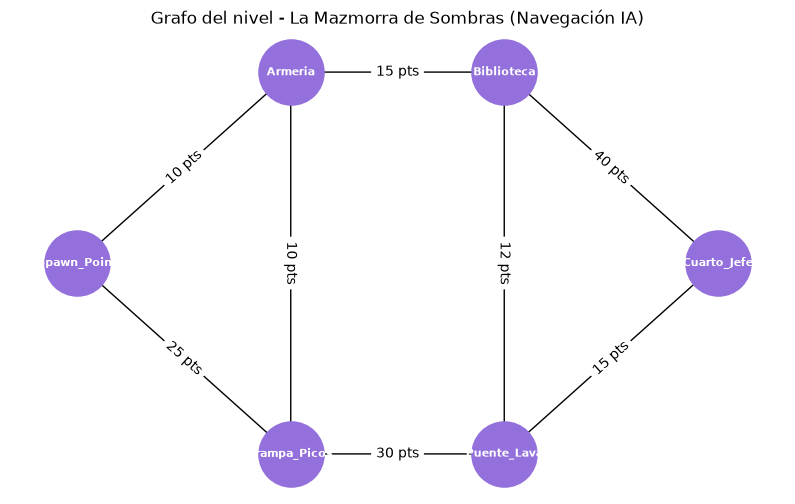

In [15]:
# Dibujamos el mapa

# 1. Posiciones 2D estimadas para dibujar el nivel
posiciones_nivel = {
    "Spawn_Point": (0, 2),
    "Armeria": (2, 3),
    "Trampa_Picos": (2, 1),
    "Biblioteca": (4, 3),
    "Puente_Lava": (4, 1),
    "Cuarto_Jefe": (6, 2)
}

# 2. Configurar gráfica
plt.figure(figsize=(10, 6))

# 3. Renderizar nodos y conexiones
nx.draw_networkx_nodes(mapa_juego, posiciones_nivel,
                       node_size=2200,
                       node_color="mediumpurple")

nx.draw_networkx_edges(mapa_juego, posiciones_nivel,
                       arrowstyle="->",
                       arrowsize=20,
                       edge_color="black")

nx.draw_networkx_labels(mapa_juego, posiciones_nivel,
                        font_size=8,
                        font_color="white",
                        font_weight="bold")

# 4. Mostrar el costo de cada camino
etiquetas_costo = nx.get_edge_attributes(mapa_juego, "weight")

nx.draw_networkx_edge_labels(
    mapa_juego,
    posiciones_nivel,
    edge_labels={
        (u, v): f"{w} pts"
        for (u, v), w in etiquetas_costo.items()
    }
)

# 5. Título del gráfico
plt.title("Grafo del nivel - La Mazmorra de Sombras (Navegación IA)")

plt.axis("off")
plt.show()